In [1]:
#CELL 1
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import os
os.getcwd()




'c:\\Users\\Mian Umer\\Desktop\\MLProject\\MLProject\\notebooks'

In [2]:
# CELL 2
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
DATASET_PATH = "../dataset/"


In [1]:
#CELL 3
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augment data during training 
train_datagen = ImageDataGenerator( 
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
     r'D:\HAD AI Project\AiProject\dataset',  # Path to your training data
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)




num_classes = train_generator.num_classes
print("Total Classes:", num_classes)


Found 129 images belonging to 13 classes.
Total Classes: 13


In [ ]:
#CELL 4
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

# Define the base model (MobileNetV2 without the top layers)
base_model = MobileNetV2(
    weights='imagenet',  # Load pre-trained weights from ImageNet
    include_top=False,   # Exclude the final fully connected layer
    input_shape=(224, 224, 3)  # Input shape for the model red, green, blue RGB
)

# Fine-tuning setup
base_model.trainable = True
fine_tune_at = 100  # Start fine-tuning after this layer

# Freeze all layers before the fine-tuning layers
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Add custom layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)  # Output layer for multi-class classification

# Full model definition
model = Model(inputs=base_model.input, outputs=output)

# Recompile the model with the updated base model
model.compile(optimizer=Adam(learning_rate=0.00005), loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary to confirm
# model.summary()




Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,423,629 (9.25 MB)

 Trainable params: 2,027,085 (7.73 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [5]:
#CELL 5
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dropout, Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model

# Adding Dropout and L2 regularization
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.7)(x)  # Dropout after dense layer
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Recompile the model after making changes
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Save the best model during training
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

# Validation data generator (same as train_generator)
val_datagen = ImageDataGenerator(rescale=1./255)

val_data = val_datagen.flow_from_directory(
    r'D:\HAD AI Project\AiProject\dataset',  # Correct validation data path
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Use a smaller learning rate
optimizer = Adam(learning_rate=5e-5)

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with both callbacks
history = model.fit(
    train_generator, 
    epochs=50, 
    validation_data=val_data,  # Now val_data is defined
    verbose=1,  # Detailed logs for each epoch
    callbacks=[early_stopping, model_checkpoint]
)


Found 129 images belonging to 13 classes.
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0785 - loss: 3.4623

5/5 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.1008 - loss: 3.3719 - val_accuracy: 0.0853 - val_loss: 2.8234
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1112 - loss: 3.0311

5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.1008 - loss: 3.0750 - val_accuracy: 0.1085 - val_loss: 2.7224
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1147 - loss: 2.8405    

5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.1240 - loss: 3.0442 - val_accuracy: 0.1318 - val_loss: 2.6343
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1290 - loss: 2.7653

5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.1008 - loss: 2.8427 - val_accuracy: 0.1550 - val_loss: 2.5318
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1036 - loss: 2.6905    

...

5/5 ━━━━━━━━━━━━━━━━━━━━ 31177s 7793s/step - accuracy: 0.2403 - loss: 2.2828 - val_accuracy: 0.3488 - val_loss: 2.0536
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2098 - loss: 2.3200 

5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.2171 - loss: 2.3482 - val_accuracy: 0.3953 - val_loss: 1.9842
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1843 - loss: 2.2694    

5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.2558 - loss: 2.2647 - val_accuracy: 0.4264 - val_loss: 1.9213
Epoch 13/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2324 - loss: 2.1502

5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.2636 - loss: 2.1390 - val_accuracy: 0.4651 - val_loss: 1.8577
Epoch 14/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2507 - loss: 2.2118

5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.2248 - loss: 2.2402 - val_accuracy: 0.5194 - val_loss: 1.7941
Epoch 15/50
4/5 ━━━━━━━━━━━━━━━━━━━━ 3s 4s/step - accuracy: 0.1840 - loss: 2.0993  

In [ ]:
#CELL 7
# Predict on the validation data
val_preds = model.predict(val_data, batch_size=BATCH_SIZE)

# Print the first few predictions
print(val_preds[:5])  # Check the first 5 predictions


5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step   
[[0.01662308 0.00435962 0.03454346 0.01562272 0.00294885 0.02376381
  0.01211733 0.0410441  0.00784658 0.6977386  0.06667903 0.00703078
  0.06968207]
 [0.02857467 0.55449665 0.00776213 0.0951642  0.06910836 0.05019519
  0.02530695 0.0025049  0.02845185 0.02641288 0.06905466 0.0407358
  0.0022317 ]
 [0.28212717 0.02917045 0.00754287 0.23136395 0.01455882 0.04929827
  0.01963538 0.00997409 0.10083588 0.01267548 0.01674891 0.22124067
  0.00482804]
 [0.0205295  0.0111821  0.00420866 0.2626749  0.05002983 0.04104396
  0.01421306 0.00155302 0.02618431 0.02336916 0.54089546 0.00113379
  0.00298223]
 [0.44632438 0.02767196 0.01398113 0.19747268 0.05719235 0.03467925
  0.01602531 0.0101409  0.07054871 0.02125015 0.03356891 0.06381383
  0.00733046]]


In [ ]:
# CELL 8
import os

print("Path Exists:", os.path.exists("../dataset/"))
print("Folders:", os.listdir("../dataset/"))


Path Exists: True
Folders: ['calling', 'clapping', 'cycling', 'drinking', 'eating', 'fighting', 'happy', 'jumping', 'laptop', 'running', 'sitting', 'sleeping', 'walking']


In [ ]:
# CELL 9

import os

for folder in os.listdir("../dataset/"):
    path = "../dataset/" + folder
    print(folder, "→", len(os.listdir(path)), "files")


calling → 10 files
clapping → 10 files
cycling → 10 files
drinking → 10 files
eating → 10 files
fighting → 10 files
happy → 5 files
jumping → 5 files
laptop → 10 files
running → 15 files
sitting → 14 files
sleeping → 15 files
walking → 5 files


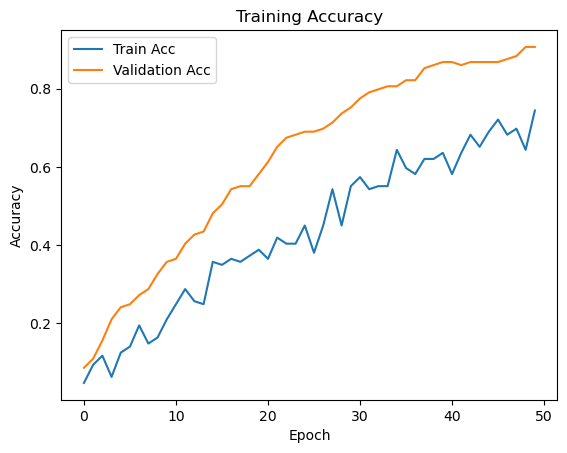

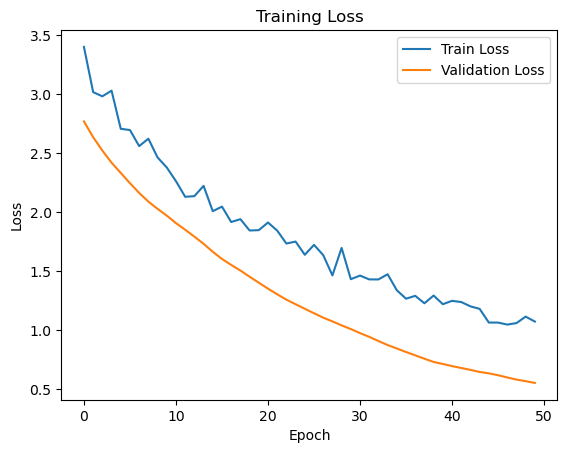

In [ ]:
# CELL 10
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train Acc', 'Validation Acc'])
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()




In [ ]:
model.save("activity_model.h5")
print("Model saved successfully!")


Model saved successfully!
